In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("\nLibraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")


Libraries imported successfully
Pandas version: 3.0.0
Numpy version: 2.3.5


In [2]:
data_path = r'C:\Users\ZEYNEP\house_price_prediction\data\cleaned_kc_house_data.csv'
df = pd.read_csv(data_path)

print("\nCleaned dataset loaded successfully")
print(f"Source: {data_path}")
print(f"Shape: {df.shape}")

print("\nDataset Info:")
print(f" Rows: {df.shape[0]:,}")
print(f" Columns: {df.shape[1]:}")
print(f" Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nData types summary:")
print(df.dtypes.value_counts())

print("\nFirst 5 rows:")
print(df.head())

print("\nTarget variable (price) statistics:")
print(f" Mean: ${df['price'].mean():,.2f}")
print(f" Median: ${df['price'].median():,.2f}")
print(f" Min: ${df['price'].min():,.2f}")
print(f" Max: ${df['price'].max():,.2f}")


Cleaned dataset loaded successfully
Source: C:\Users\ZEYNEP\house_price_prediction\data\cleaned_kc_house_data.csv
Shape: (21602, 21)

Dataset Info:
 Rows: 21,602
 Columns: 21
 Memory usage: 4.68 MB

Data types summary:
int64      15
float64     5
str         1
Name: count, dtype: int64

First 5 rows:
           id        date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  2014-10-13  221900.0         3       1.00         1180   
1  6414100192  2014-12-09  538000.0         3       2.25         2570   
2  5631500400  2015-02-25  180000.0         2       1.00          770   
3  2487200875  2014-12-09  604000.0         4       3.00         1960   
4  1954400510  2015-02-18  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
0      5650     1.0           0     0          3      7        1180   
1      7242     2.0           0     0          3      7        2170   
2     10000     1.0           0     0        

Create Temporal Features

Reference year for calculations: 2025

Created 'house_age' feature
 Range: 10 - 125 years
 Mean: 54.0 years

Created 'was_renovated' feature (binary)
 Renovated houses: 914 (4.23%)
 Not renovated: 20688 (95.77%)

Created 'years_since_renovation' feature
 For renovated houses - Range: 10 - 91 years
 For not renovated houses: 0 (default)


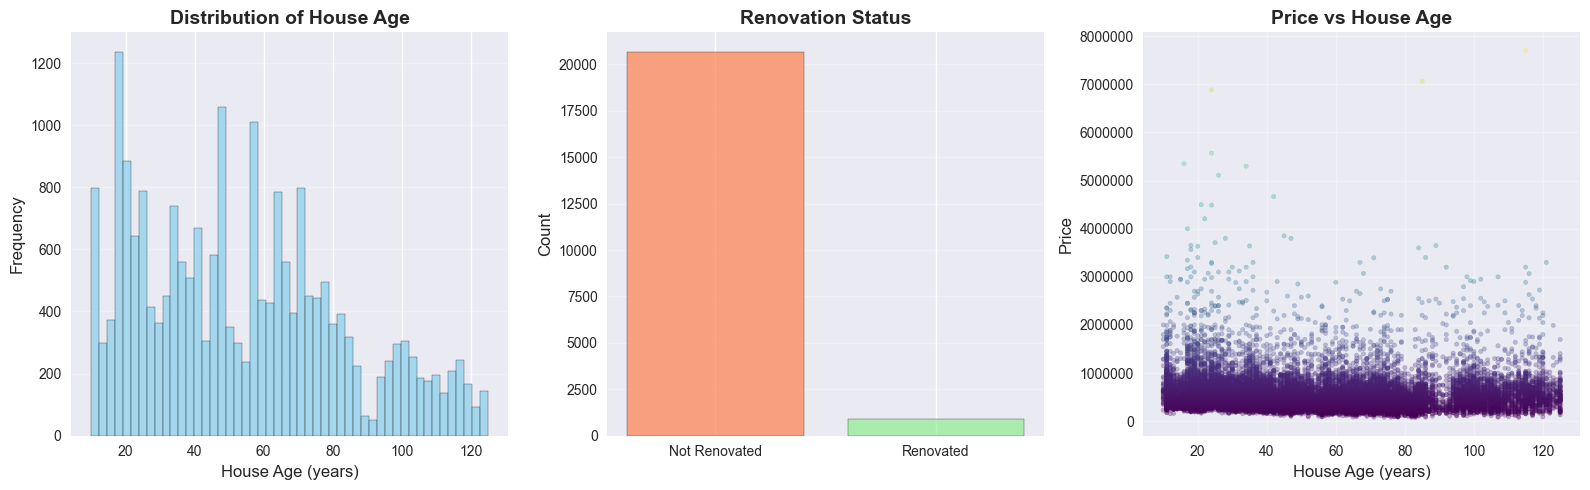


Temporal features created successfully
New features: house_age, was_renovated, years_since_renovation
Current dataset shape: (21602, 24)


In [3]:
print("Create Temporal Features")
print("="*80)

REFERENCE_YEAR = 2025

print(f"\nReference year for calculations: {REFERENCE_YEAR}")

df['house_age'] = REFERENCE_YEAR - df['yr_built']
print(f"\nCreated 'house_age' feature")
print(f" Range: {df['house_age'].min()} - {df['house_age'].max()} years")
print(f" Mean: {df['house_age'].mean():.1f} years")

df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)
print(f"\nCreated 'was_renovated' feature (binary)")
print(f" Renovated houses: {df['was_renovated'].sum()} ({df['was_renovated'].sum()/len(df)*100:.2f}%)")
print(f" Not renovated: {(df['was_renovated']==0).sum()} ({(df['was_renovated']==0).sum()/len(df)*100:.2f}%)")

df['years_since_renovation'] = 0
renovated_mask = df['yr_renovated'] > 0
df.loc[renovated_mask, 'years_since_renovation'] = REFERENCE_YEAR - df.loc[renovated_mask, 'yr_renovated']
print(f"\nCreated 'years_since_renovation' feature")
print(f" For renovated houses - Range: {df.loc[renovated_mask, 'years_since_renovation'].min():.0f} - {df.loc[renovated_mask, 'years_since_renovation'].max():.0f} years")
print(f" For not renovated houses: 0 (default)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['house_age'], bins=50, edgecolor='black', alpha=0.7, color ='skyblue')
axes[0].set_xlabel('House Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Age', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

renovation_counts = df['was_renovated'].value_counts()
axes[1].bar(['Not Renovated', 'Renovated'], [renovation_counts[0], renovation_counts[1]], color = ['coral', 'lightgreen'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Renovation Status', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

axes[2].scatter(df['house_age'], df['price'], alpha=0.3, s=10, c=df['price'], cmap='viridis')
axes[2].set_xlabel('House Age (years)', fontsize=12)
axes[2].set_ylabel('Price', fontsize=12)
axes[2].set_title('Price vs House Age', fontsize=14, fontweight='bold')
axes[2].ticklabel_format(style='plain', axis='y')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTemporal features created successfully")
print(f"New features: house_age, was_renovated, years_since_renovation")
print(f"Current dataset shape: {df.shape}")

Create Location Features

Created 'is_north' feature (lat > 47.5718)
 North houses: 10797 (49.98%)
 South houses: 10805 (50.02%)
 North median price: $560,000.00
 South median price: $340,000.00
 Price difference: 64.7%

 Created 'is_east' feature (long > -122.23)
 East houses: 10778 (49.89%)
 West houses: 10824 (50.11%)
 East median price: $475,000.00
 West median price: $430,000.00
 Price difference: 10.5%

Created 'is_premium_area' feature (lat>47.6 AND long>-122.2)
 Premium area houses: 3275 (15.16%)
 Premium area median price: $572,500.00
 Regular area median price: $425,000.00
 Price difference: 34.7%


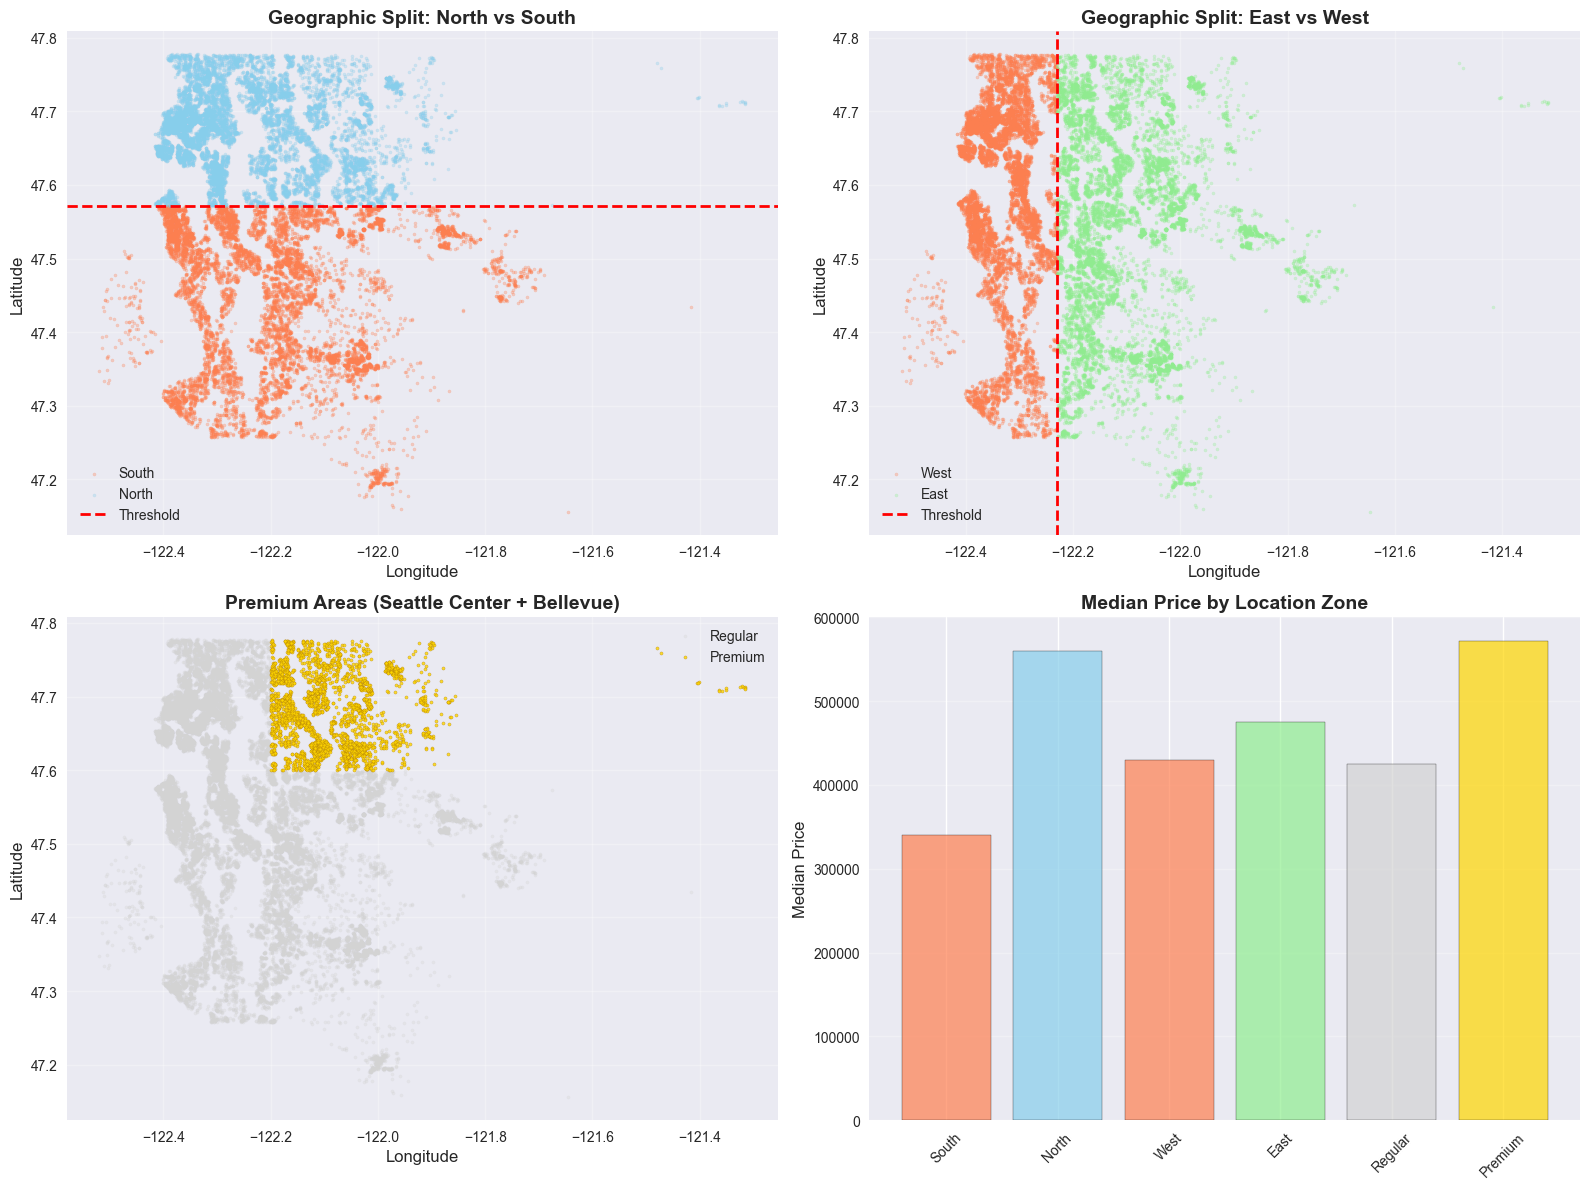


Location features created successfully
New features: is_north, is_east, is_premium_area
Current dataset shape: (21602, 27)


In [4]:
print("Create Location Features")
print("="*80)

#From EDA: Geographic zones with price premiums
#North: median_lat = 47.5718 
#East: median_long = -122.2300 

#1. Is north (higher price zone)
NORTH_THRESHOLD = 47.5718
df['is_north'] = (df['lat'] > NORTH_THRESHOLD).astype(int)
print(f"\nCreated 'is_north' feature (lat > {NORTH_THRESHOLD})")
print(f" North houses: {df['is_north'].sum()} ({df['is_north'].sum()/len(df)*100:.2f}%)")
print(f" South houses: {(df['is_north']==0).sum()} ({(df['is_north']==0).sum()/len(df)*100:.2f}%)")

north_median = df[df['is_north']==1]['price'].median()
south_median = df[df['is_north']==0]['price'].median()
print(f" North median price: ${north_median:,.2f}")
print(f" South median price: ${south_median:,.2f}")
print(f" Price difference: {(north_median/south_median-1)*100:.1f}%")

#2. Is east (higher price zone)
EAST_THRESHOLD = -122.2300
df['is_east'] = (df['long'] > EAST_THRESHOLD).astype(int)
print(f"\n Created 'is_east' feature (long > {EAST_THRESHOLD})")
print(f" East houses: {df['is_east'].sum()} ({df['is_east'].sum()/len(df)*100:.2f}%)")
print(f" West houses: {(df['is_east']==0).sum()} ({(df['is_east']==0).sum()/len(df)*100:.2f}%)")

east_median = df[df['is_east']==1]['price'].median()
west_median = df[df['is_east']==0]['price'].median()
print(f" East median price: ${east_median:,.2f}")
print(f" West median price: ${west_median:,.2f}")
print(f" Price difference: {(east_median/west_median-1)*100:.1f}%")

#3. Is premium area (both North and East)
df['is_premium_area'] = ((df['lat'] > 47.6) & (df['long'] > -122.2)).astype(int)
print(f"\nCreated 'is_premium_area' feature (lat>47.6 AND long>-122.2)")
print(f" Premium area houses: {df['is_premium_area'].sum()} ({df['is_premium_area'].sum()/len(df)*100:.2f}%)")
premium_median = df[df['is_premium_area']==1]['price'].median()
regular_median = df[df['is_premium_area']==0]['price'].median()
print(f" Premium area median price: ${premium_median:,.2f}")
print(f" Regular area median price: ${regular_median:,.2f}")
print(f" Price difference: {(premium_median/regular_median-1)*100:,.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Map North vs South
axes[0, 0].scatter(df[df['is_north']==0]['long'], df[df['is_north']==0]['lat'], alpha=0.3, s=5, c='coral', label='South')
axes[0, 0].scatter(df[df['is_north']==1]['long'], df[df['is_north']==1]['lat'], alpha=0.3, s=5, c='skyblue', label='North')
axes[0, 0].axhline(NORTH_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title('Geographic Split: North vs South', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

#Map East vs West
axes[0, 1].scatter(df[df['is_east']==0]['long'], df[df['is_east']==0]['lat'], alpha=0.3, s=5, c='coral', label='West')
axes[0, 1].scatter(df[df['is_east']==1]['long'], df[df['is_east']==1]['lat'], alpha=0.3, s=5, c='lightgreen', label='East')
axes[0, 1].axvline(EAST_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 1].set_ylabel('Latitude', fontsize=12)
axes[0, 1].set_title('Geographic Split: East vs West', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

#Map Premium Areas
axes[1, 0].scatter(df[df['is_premium_area']==0]['long'], df[df['is_premium_area']==0]['lat'], alpha=0.3, s=5, c='lightgray', label='Regular')
axes[1, 0].scatter(df[df['is_premium_area']==1]['long'], df[df['is_premium_area']==1]['lat'], alpha=0.8, s=5, c='gold', label='Premium', edgecolors='darkgoldenrod')
axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 0].set_ylabel('Latitude', fontsize=12)
axes[1, 0].set_title('Premium Areas (Seattle Center + Bellevue)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

#Price comparison bar chart
categories = ['South', 'North', 'West', 'East', 'Regular', 'Premium']
prices = [south_median, north_median, west_median, east_median, regular_median, premium_median]
colors = ['coral', 'skyblue','coral', 'lightgreen', 'lightgray', 'gold']

axes[1, 1].bar(categories, prices, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Median Price', fontsize=12)
axes[1, 1].set_title('Median Price by Location Zone', fontsize=14, fontweight='bold')
axes[1, 1].ticklabel_format(style='plain', axis='y')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nLocation features created successfully")
print(f"New features: is_north, is_east, is_premium_area")
print(f"Current dataset shape: {df.shape}")

Create Derived Features

Created 'price_per_sqft' feature
 Range: $87.59 - $810.14 per sqft
 Mean: $264.13 per sqft
 Median: $244.61 per sqft

Created 'total_rooms' feature
 Range: 0.8 - 16.5 rooms
 Mean: 5.5 rooms

Created 'has_basement' feature
 With basement: 8486 (39.28%)
 Without basement: 13116 (60.72%)
 With basement median price: $515,000.00
 Without basement median price: $411,679.00
 Price difference: 25.1%


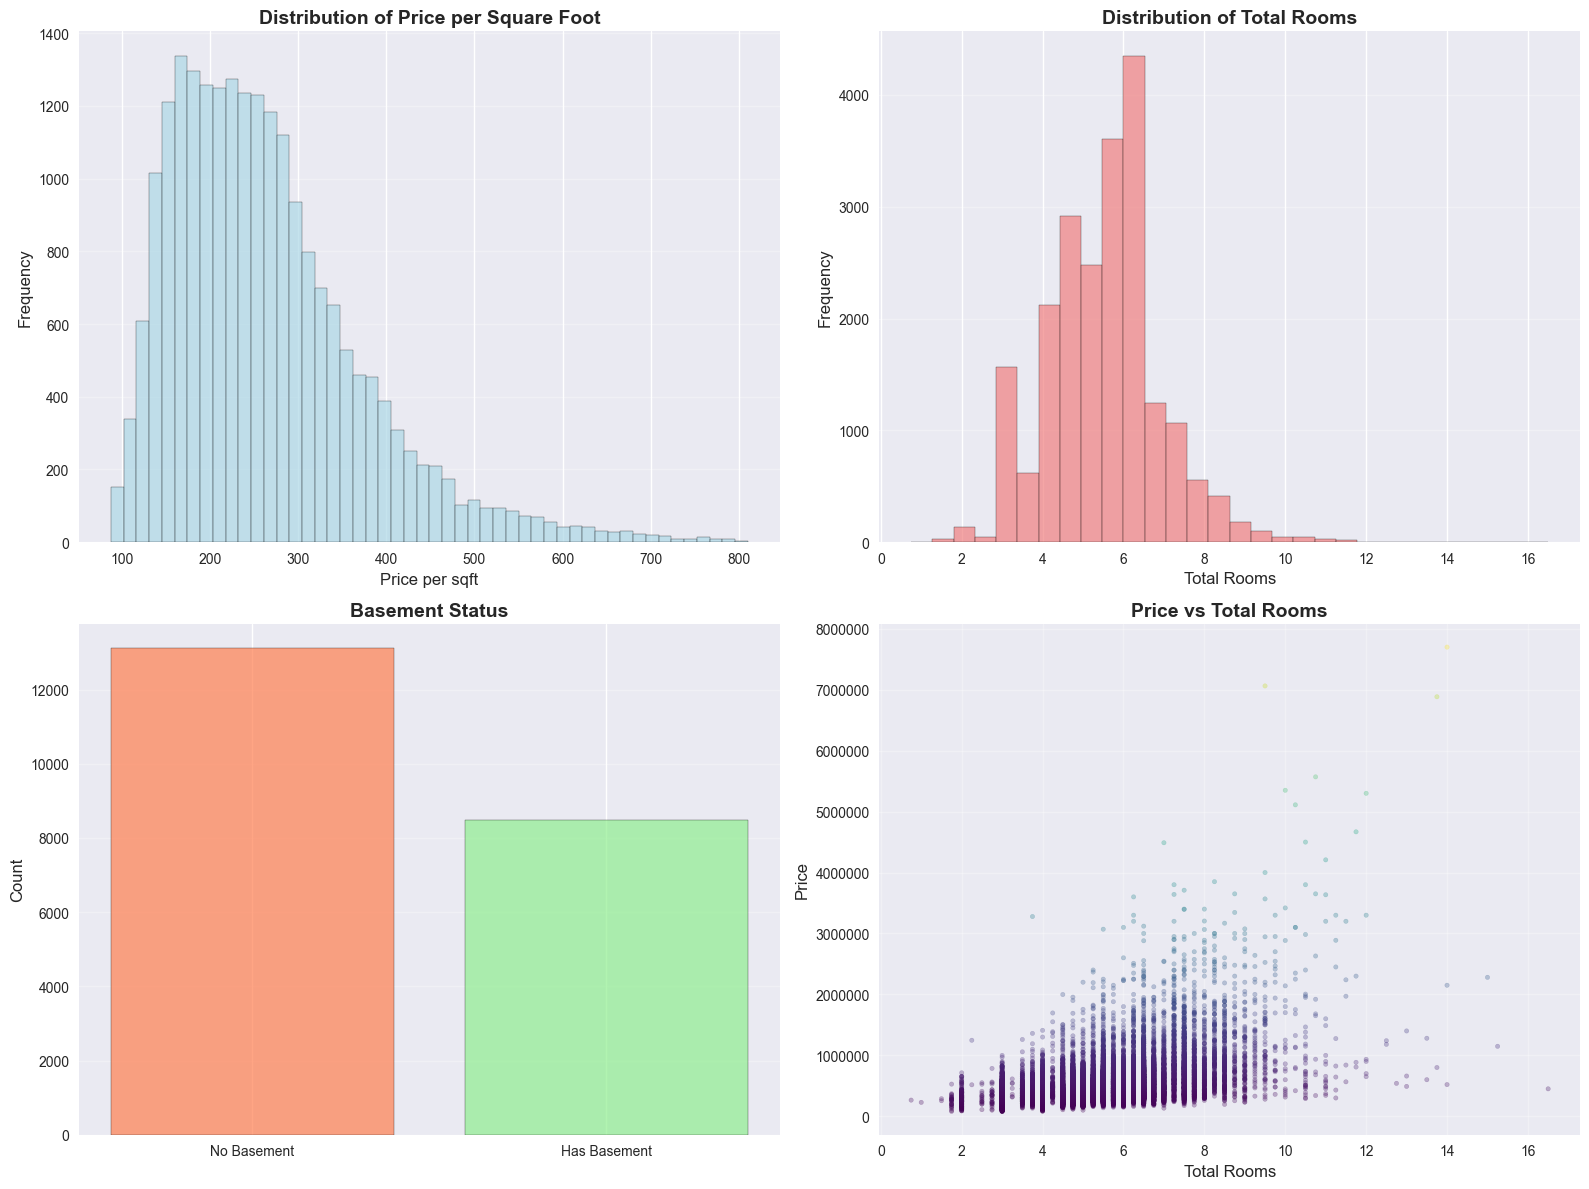


Derived features created successfully
New features: price_per_sqft, total_rooms, has_basement
Current dataset shape: (21602, 30)


In [5]:
print("Create Derived Features")
print("="*80)

#Price per square Foot
df['price_per_sqft'] = df['price'] / df['sqft_living']
print(f"\nCreated 'price_per_sqft' feature")
print(f" Range: ${df['price_per_sqft'].min():.2f} - ${df['price_per_sqft'].max():.2f} per sqft")
print(f" Mean: ${df['price_per_sqft'].mean():.2f} per sqft")
print(f" Median: ${df['price_per_sqft'].median():.2f} per sqft")

#Total rooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
print(f"\nCreated 'total_rooms' feature")
print(f" Range: {df['total_rooms'].min():.1f} - {df['total_rooms'].max():.1f} rooms")
print(f" Mean: {df['total_rooms'].mean():.1f} rooms")

#Has basement (binary)
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)
print(f"\nCreated 'has_basement' feature")
print(f" With basement: {df['has_basement'].sum()} ({df['has_basement'].sum()/len(df)*100:.2f}%)")
print(f" Without basement: {(df['has_basement']==0).sum()} ({(df['has_basement']==0).sum()/len(df)*100:.2f}%)")

#Price comparison
basement_median = df[df['has_basement']==1]['price'].median()
no_basement_median = df[df['has_basement']==0]['price'].median()
print(f" With basement median price: ${basement_median:,.2f}")
print(f" Without basement median price: ${no_basement_median:,.2f}")
print(f" Price difference: {(basement_median/no_basement_median - 1)*100:.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df['price_per_sqft'], bins=50, edgecolor='black', alpha=0.7, color='lightblue')
axes[0, 0].set_xlabel('Price per sqft', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Price per Square Foot', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

#Total Room Distribution
axes[0, 1].hist(df['total_rooms'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Total Rooms', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Total Rooms', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

#Basement Status
basement_counts = df['has_basement'].value_counts()
axes[1, 0].bar(['No Basement', 'Has Basement'], [basement_counts[0], basement_counts[1]], color = ['coral', 'lightgreen'], edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('Basement Status', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

#Price vs Total Rooms
axes[1, 1].scatter(df['total_rooms'], df['price'], alpha=0.3, s=10, c=df['price'], cmap='viridis')
axes[1, 1].set_xlabel('Total Rooms', fontsize=12)
axes[1, 1].set_ylabel('Price', fontsize=12)
axes[1, 1].set_title('Price vs Total Rooms', fontsize=14, fontweight='bold')
axes[1, 1].ticklabel_format(style='plain', axis='y')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDerived features created successfully")
print(f"New features: price_per_sqft, total_rooms, has_basement")
print(f"Current dataset shape: {df.shape}")

In [6]:
print("Handle Multicollinearity")
print("="*80)

#From EDA: sqft_living and sqft_above have 0.88 correlation
#We will keep sqft_living (more comprehensive) and drop sqft_above

print("\nMulticollinearity Issue:")
print(" sqft_living - sqft_above correlation: 0.88 (very high)")
print(" Decision: Keep sqft_living, Drop sqft_above")
print(" Reason: sqft_living = sqft_above + sqft_basement (more comprehensive)")

#Check if sqft_above exists
if 'sqft_above' in df.columns:
    print(f"\nDropping 'sqft_above' column...")
    df = df.drop('sqft_above', axis=1)
    print(f" Column dropped successfully")
else:
    print(f"\n'sqft_above' column not found")

print(f"\nMulticollinearity handled")
print(f"Current dataset shape: {df.shape}")

#Verify correlation matrix for remaining numaric features
print("\nVerifying remaining high correlations (>0.85)...")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

#Find high correlations (excluding diagonal)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.85:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
if high_corr:
    print(f"\nFound {len(high_corr)} high correlations(s):")
    for corr in high_corr:
        print(f" {corr['Feature 1']} - {corr['Feature 2']}: {corr['Correlation']:.3f}")
else:
    print("\nNo problematic correlations (>0.85) remaining")

print(f"\nRemaining columns ({len(df.columns)}):")
print(f" {list(df.columns)}")

Handle Multicollinearity

Multicollinearity Issue:
 sqft_living - sqft_above correlation: 0.88 (very high)
 Decision: Keep sqft_living, Drop sqft_above
 Reason: sqft_living = sqft_above + sqft_basement (more comprehensive)

Dropping 'sqft_above' column...
 Column dropped successfully

Multicollinearity handled
Current dataset shape: (21602, 29)

Verifying remaining high correlations (>0.85)...

Found 6 high correlations(s):
 bedrooms - total_rooms: 0.895
 bathrooms - total_rooms: 0.851
 yr_built - house_age: -1.000
 yr_renovated - was_renovated: 1.000
 yr_renovated - years_since_renovation: 0.875
 was_renovated - years_since_renovation: 0.879

Remaining columns (29):
 ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'was_renovated', 'years_since_renovation', 'is_north', 'is_east', 'is_premium_

In [7]:
print("Drop Redundant Features")
print("="*80)

print("\nDropping highly correlated redundant features:")

#Drop yr_built (we have house_age)
if 'yr_built' in df.columns:
    print("\n 1. Dropping 'yr_built':")
    print("  Reason: Good correlation with house_age (-1.000)")
    print("  We keep: house_age (more interpretable)")
    df = df.drop('yr_built', axis=1)
    print("  Dropped")

#Drop yr_renovated (we have was_renovated and years_since_renovation)
if 'yr_renovated' in df.columns:
    print("\n 2. Dropping 'yr_renovated':")
    print("  Reason: Good correlation with was_renovated (1.000)")
    print("  We keep: was_renovated - years_since_renovation")
    df = df.drop('yr_renovated', axis=1)
    print("  Dropped")

#Drop total_rooms (we have bedrooms and bathrooms)
if 'total_rooms' in df.columns:
    print("\n 3. Dropping 'total_rooms':")
    print("  Reason: High correlation with bedrooms (0.895) and bathrooms (0.851)")
    print("  We keep: Bedrooms +  bathrooms (original features)")
    df = df.drop('total_rooms', axis=1)
    print("  Dropped") 

print(f"\nRedundant features dropped")
print(f"Current dataset shape: {df.shape}")

#Final verification
print("\nFinal correlation check (>0.85)...")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.85:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
if high_corr:
    print(f"\nRemaining high correlations ({len(high_corr)}):")
    for corr in high_corr:
        print(f" {corr['Feature 1']} - {corr['Feature 2']}: {corr['Correlation']:.3f}")
    print("\nNote: was_renovated - years_since_renovation is acceptable")
    print("       (different information: binary vs continuous)")
else:
    print("\nNo problematic correlations (>0.85) remaining") 

print(f"\nFinal feature count: {len(df.columns)} columns")
print(f"\nRemaining columns:")
print(f" {list(df.columns)}")

Drop Redundant Features

Dropping highly correlated redundant features:

 1. Dropping 'yr_built':
  Reason: Good correlation with house_age (-1.000)
  We keep: house_age (more interpretable)
  Dropped

 2. Dropping 'yr_renovated':
  Reason: Good correlation with was_renovated (1.000)
  We keep: was_renovated - years_since_renovation
  Dropped

 3. Dropping 'total_rooms':
  Reason: High correlation with bedrooms (0.895) and bathrooms (0.851)
  We keep: Bedrooms +  bathrooms (original features)
  Dropped

Redundant features dropped
Current dataset shape: (21602, 26)

Final correlation check (>0.85)...

Remaining high correlations (1):
 was_renovated - years_since_renovation: 0.879

Note: was_renovated - years_since_renovation is acceptable
       (different information: binary vs continuous)

Final feature count: 26 columns

Remaining columns:
 ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement'

In [8]:
print("Encode Categorical Variables")
print("="*80)

categorical_features = ['waterfront', 'view', 'condition', 'grade', 'zipcode']

print(f"Categorical features to encode: {categorical_features}")

print("\nUnique value counts:")
for col in categorical_features:
    if col in df.columns:
        print(f" {col}: {df[col].nunique()} unique values")

print("-"*80)
print("Encoding Strategy:")
print("-"*80)

#Binary features (already encoded)
print("\n1. Binary Features (No change needed):")
print("   - waterfront: Already 0/1")
print("   - is_north: Already 0/1")
print("   - is_east: Already 0/1")
print("   - is_premium_area: Already 0/1")
print("   - was_renovated: Already 0/1")
print("   - has_basement: Already 0/1")

# 2. Ordinal features (keep as numeric)
print("\n2. Ordinal Features (Keep as numeric):")
print("   - view (0-4): 0=No view, 4=Excellent view")
print("   - condition (1-5): 1=Poor, 5=Excellent")
print("   - grade (1-13): 1=Poor, 13=Luxury mansion")
print("   Decision: Keep as numeric (natural ordering)")

# 3. High cardinality: zipcode
print("\n3. High Cardinality - zipcode:")
print(f"   Unique values: {df['zipcode'].nunique()}")
print("   DECISION: DROP zipcode")
print("   Reason: We already have:")
print("   - lat, long (precise location)")
print("   - is_north, is_east, is_premium_area (location zones)")
print("   - zipcode would add 70 columns (too complex)")

#Drop zipcode
if 'zipcode' in df.columns:
    print("Dropping 'zipcode' column")
    df = df.drop('zipcode', axis = 1)
    print("Dropped Successfully")

print(f"Categorical encoding complete")
print(f"Current shape of the dataset: {df.shape}")
print(f"Final feature count: {len(df.columns)} columns")

Encode Categorical Variables
Categorical features to encode: ['waterfront', 'view', 'condition', 'grade', 'zipcode']

Unique value counts:
 waterfront: 2 unique values
 view: 5 unique values
 condition: 5 unique values
 grade: 11 unique values
 zipcode: 70 unique values
--------------------------------------------------------------------------------
Encoding Strategy:
--------------------------------------------------------------------------------

1. Binary Features (No change needed):
   - waterfront: Already 0/1
   - is_north: Already 0/1
   - is_east: Already 0/1
   - is_premium_area: Already 0/1
   - was_renovated: Already 0/1
   - has_basement: Already 0/1

2. Ordinal Features (Keep as numeric):
   - view (0-4): 0=No view, 4=Excellent view
   - condition (1-5): 1=Poor, 5=Excellent
   - grade (1-13): 1=Poor, 13=Luxury mansion
   Decision: Keep as numeric (natural ordering)

3. High Cardinality - zipcode:
   Unique values: 70
   DECISION: DROP zipcode
   Reason: We already have:
  

In [9]:
print("FEATURE SCALING")
print("="*80)

from sklearn.preprocessing import StandardScaler

print("\nFeature scaling strategy:")
print("  Method: StandardScaler (mean=0, std=1)")
print("  Apply to: Continuous numerical features only")
print("  Skip: Binary features, target variable (price), ID, date")

# Identify features to scale
continuous_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors','sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15','house_age', 'years_since_renovation', 'price_per_sqft']

# Ordinal features (keep as is - already on reasonable scale)
ordinal_features = ['view', 'condition', 'grade']

# Binary features (don't scale - already 0/1)
binary_features = ['waterfront', 'is_north', 'is_east', 'is_premium_area', 'was_renovated', 'has_basement']

print(f"\nFeatures to scale ({len(continuous_features)}):")
for feat in continuous_features:
    if feat in df.columns:
        print(f"  - {feat}")

print(f"\nOrdinal features - keep as is ({len(ordinal_features)}):")
for feat in ordinal_features:
    print(f"  - {feat}")

print(f"\nBinary features - don't scale ({len(binary_features)}):")
for feat in binary_features:
    print(f"  - {feat}")

print("\nIMPORTANT: Scaling will be applied AFTER train-test split!")
print("   Reason: Prevent data leakage")
print("   - Fit scaler on TRAINING data only")
print("   - Transform both TRAINING and TEST data")

print(f"\nFeature scaling strategy defined")
print(f"  Ready for train-test split")
print(f"Current dataset shape: {df.shape}")

# Display sample statistics before scaling
print("\nSample statistics (before scaling):")
sample_features = ['sqft_living', 'house_age', 'price_per_sqft']
for feat in sample_features:
    if feat in df.columns:
        print(f"  {feat}:")
        print(f"    Mean: {df[feat].mean():.2f}")
        print(f"    Std: {df[feat].std():.2f}")
        print(f"    Min: {df[feat].min():.2f}")
        print(f"    Max: {df[feat].max():.2f}")

FEATURE SCALING

Feature scaling strategy:
  Method: StandardScaler (mean=0, std=1)
  Apply to: Continuous numerical features only
  Skip: Binary features, target variable (price), ID, date

Features to scale (13):
  - bedrooms
  - bathrooms
  - sqft_living
  - sqft_lot
  - floors
  - sqft_basement
  - lat
  - long
  - sqft_living15
  - sqft_lot15
  - house_age
  - years_since_renovation
  - price_per_sqft

Ordinal features - keep as is (3):
  - view
  - condition
  - grade

Binary features - don't scale (6):
  - waterfront
  - is_north
  - is_east
  - is_premium_area
  - was_renovated
  - has_basement

IMPORTANT: Scaling will be applied AFTER train-test split!
   Reason: Prevent data leakage
   - Fit scaler on TRAINING data only
   - Transform both TRAINING and TEST data

Feature scaling strategy defined
  Ready for train-test split
Current dataset shape: (21602, 25)

Sample statistics (before scaling):
  sqft_living:
    Mean: 2080.13
    Std: 918.16
    Min: 370.00
    Max: 13540.00

In [10]:
print("Train Test Split")
print("="*80)

from sklearn.model_selection import train_test_split

exclude_cols = ['id', 'date', 'price']

#Create feature matrix X and target vector y
X = df.drop(columns=exclude_cols)
y = df['price']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

print(f"Features in X ({len(X.columns)}):")
print(f" {list(X.columns)}")

TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"Test Size: {TEST_SIZE*100:.0f}%")
print(f"Train size: {(1-TEST_SIZE)*100:.0f}%")
print(f"Random state: {RANDOM_STATE} (for reproducibility)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_SIZE, random_state=RANDOM_STATE)

print("Split Complete")
print(f" Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("Verifying Split:")
print(f" X_train shape: {X_train.shape}")
print(f" X_test shape: {X_test.shape}")
print(f" y_train shape: {y_train.shape}")
print(f" y_test shape: {y_test.shape}")

# Price distribution check
print(f"\nPrice distribution:")
print(f"  Train set:")
print(f"    Mean: ${y_train.mean():,.2f}")
print(f"    Median: ${y_train.median():,.2f}")
print(f"    Min: ${y_train.min():,.2f}")
print(f"    Max: ${y_train.max():,.2f}")
print(f"  Test set:")
print(f"    Mean: ${y_test.mean():,.2f}")
print(f"    Median: ${y_test.median():,.2f}")
print(f"    Min: ${y_test.min():,.2f}")
print(f"    Max: ${y_test.max():,.2f}")

print(f"\nTrain-test split complete")

Train Test Split
Features (X): (21602, 22)
Target (y): (21602,)
Features in X (22):
 ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'was_renovated', 'years_since_renovation', 'is_north', 'is_east', 'is_premium_area', 'price_per_sqft', 'has_basement']
Test Size: 20%
Train size: 80%
Random state: 42 (for reproducibility)
Split Complete
 Training set: 17281 samples (80.0%)
 Test set: 4321 samples (20.0%)
Verifying Split:
 X_train shape: (17281, 22)
 X_test shape: (4321, 22)
 y_train shape: (17281,)
 y_test shape: (4321,)

Price distribution:
  Train set:
    Mean: $539,951.35
    Median: $450,000.00
    Min: $78,000.00
    Max: $7,700,000.00
  Test set:
    Mean: $540,824.84
    Median: $450,000.00
    Min: $81,000.00
    Max: $5,110,800.00

Train-test split complete


In [11]:
print("="*80)
print("FEATURE SCALING")
print("="*80)

from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale ALL features (simpler and works for all models)
print(f"\nScaling ALL {X_train.shape[1]} features...")
print("Note: Binary features will also be scaled (not a problem for ML models)")

scaler = StandardScaler()

# Fit on training data only
print(f"\nFitting scaler on TRAINING data only...")
scaler.fit(X_train)

# Transform both train and test
print(f"Transforming TRAINING data...")
X_train_scaled = scaler.transform(X_train)

print(f"Transforming TEST data...")
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (to keep column names)
X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled, 
    columns=X_test.columns, 
    index=X_test.index
)

print(f"\nFeature scaling complete!")

print(f"\nVerifying scaling (sample features):")
sample_features = ['sqft_living', 'house_age', 'price_per_sqft', 'waterfront', 'has_basement']

for feat in sample_features:
    if feat in X_train.columns:
        print(f"\n  {feat}:")
        print(f"    BEFORE scaling:")
        print(f"      Train mean: {X_train[feat].mean():.2f}, std: {X_train[feat].std():.2f}")
        print(f"    AFTER scaling:")
        print(f"      Train mean: {X_train_scaled[feat].mean():.6f}, std: {X_train_scaled[feat].std():.6f}")

print(f"\n All features scaled to mean≈0, std≈1")

# Final shapes
print(f"\n" + "="*80)
print("FINAL DATASET SHAPES")
print("="*80)
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")
print(f"  y_train:        {y_train.shape}")
print(f"  y_test:         {y_test.shape}")
print("="*80)

FEATURE SCALING

Scaling ALL 22 features...
Note: Binary features will also be scaled (not a problem for ML models)

Fitting scaler on TRAINING data only...
Transforming TRAINING data...
Transforming TEST data...

Feature scaling complete!

Verifying scaling (sample features):

  sqft_living:
    BEFORE scaling:
      Train mean: 2080.14, std: 913.22
    AFTER scaling:
      Train mean: 0.000000, std: 1.000029

  house_age:
    BEFORE scaling:
      Train mean: 53.98, std: 29.41
    AFTER scaling:
      Train mean: -0.000000, std: 1.000029

  price_per_sqft:
    BEFORE scaling:
      Train mean: 264.28, std: 110.01
    AFTER scaling:
      Train mean: -0.000000, std: 1.000029

  waterfront:
    BEFORE scaling:
      Train mean: 0.01, std: 0.09
    AFTER scaling:
      Train mean: 0.000000, std: 1.000029

  has_basement:
    BEFORE scaling:
      Train mean: 0.39, std: 0.49
    AFTER scaling:
      Train mean: -0.000000, std: 1.000029

 All features scaled to mean≈0, std≈1

FINAL DATASE

In [12]:
print("SAVE FEATURE-READY DATASETS")
print("="*80)

import pickle

#Create directory for processed data
import os
processed_dir = r'C:\Users\ZEYNEP\house_price_prediction\data\processed'
os.makedirs(processed_dir, exist_ok=True)
print(f"\nSaving processed datasets to: {processed_dir}")

#Save train and test sets
print("\nSaving datasets...")

#Scaled data (for models)
X_train_scaled.to_csv(os.path.join(processed_dir, 'X_train_scaled.csv'), index=False)
X_test_scaled.to_csv(os.path.join(processed_dir, 'X_test_scaled.csv'), index=False)
y_train.to_csv(os.path.join(processed_dir, 'y_train.csv'), index=False, header=['price'])
y_test.to_csv(os.path.join(processed_dir, 'y_test.csv'), index=False, header=['price'])
print(" X_train_scaled.csv")
print(" X_test_scaled.csv")
print(" y_train.csv")
print(" y_test.csv")

#Unscaled data (for reference/visualization)
X_train.to_csv(os.path.join(processed_dir, 'X_train_unscaled.csv'), index=False)
X_test.to_csv(os.path.join(processed_dir, 'X_test_unscaled.csv'), index=False)
print(" X_train_unscaled.csv")
print(" X_test_unscaled.csv")


#Save feature names
feature_names_path = os.path.join(processed_dir, 'feature_names.txt')
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))
print(" feature_names.txt")

#Save continuous feature names (for scaler)
continuous_features_path = os.path.join(processed_dir, 'continuous_features.txt')
with open(continuous_features_path, 'w') as f:
    f.write('\n'.join(continuous_features))
print(" continuous_features.txt")

print(f"\nAll datasets saved successfully!")

#Verify file sizes
print(f"\nFile sizes:")
for filename in os.listdir(processed_dir):
    filepath = os.path.join(processed_dir, filename)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {filename}: {size_mb:.2f} MB")

print(f"\nFeature engineering pipeline complete")
print(f"Data ready for model training")

SAVE FEATURE-READY DATASETS

Saving processed datasets to: C:\Users\ZEYNEP\house_price_prediction\data\processed

Saving datasets...
 X_train_scaled.csv
 X_test_scaled.csv
 y_train.csv
 y_test.csv
 X_train_unscaled.csv
 X_test_unscaled.csv
 feature_names.txt
 continuous_features.txt

All datasets saved successfully!

File sizes:
  continuous_features.txt: 0.00 MB
  feature_names.txt: 0.00 MB
  scaler.pkl: 0.00 MB
  X_test_scaled.csv: 1.79 MB
  X_test_unscaled.csv: 0.38 MB
  X_train_scaled.csv: 7.14 MB
  X_train_unscaled.csv: 1.52 MB
  y_test.csv: 0.04 MB
  y_train.csv: 0.17 MB

Feature engineering pipeline complete
Data ready for model training


In [13]:
import joblib
import os

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

print("\n" + "="*80)
print(" SCALER SAVED")
print("="*80)
print(f" File: {scaler_path}")
print(f" Features: {len(X_train.columns)}")
print("\n Feature names:")
for i, feat in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {feat}")
print("="*80)


 SCALER SAVED
 File: models\scaler.pkl
 Features: 22

 Feature names:
   1. bedrooms
   2. bathrooms
   3. sqft_living
   4. sqft_lot
   5. floors
   6. waterfront
   7. view
   8. condition
   9. grade
  10. sqft_basement
  11. lat
  12. long
  13. sqft_living15
  14. sqft_lot15
  15. house_age
  16. was_renovated
  17. years_since_renovation
  18. is_north
  19. is_east
  20. is_premium_area
  21. price_per_sqft
  22. has_basement


In [14]:
import joblib

test_scaler = joblib.load('models/scaler.pkl')
print("Loaded scaler features:")
print(test_scaler.feature_names_in_)
print(f"\nTotal: {len(test_scaler.feature_names_in_)}")

Loaded scaler features:
['bedrooms' 'bathrooms' 'sqft_living' 'sqft_lot' 'floors' 'waterfront'
 'view' 'condition' 'grade' 'sqft_basement' 'lat' 'long' 'sqft_living15'
 'sqft_lot15' 'house_age' 'was_renovated' 'years_since_renovation'
 'is_north' 'is_east' 'is_premium_area' 'price_per_sqft' 'has_basement']

Total: 22
